In [25]:
import numpy as np
import pandas as pd

# Constants provided by user
RHO = 1.225
MASS = 250
CDA = 0.0795
CRR = 0.00514
G = 9.81

def calculate_solar_irradiance(seconds_from_midnight):
    """Gaussian solar model based on PDF specs"""
    G_peak = 1073
    mu = 12 * 3600  # 12:00 PM
    sigma = 11600
    return G_peak * np.exp(-((seconds_from_midnight - mu)**2) / (2 * sigma**2))

def get_mechanical_power(velocity, slope_rad):
    """Power equation derived from Foundation Section"""
    f_drag = 0.5 * RHO * CDA * velocity**2
    f_rr = MASS * G * CRR * np.cos(slope_rad)
    f_gravity = MASS * G * np.sin(slope_rad)

    p_mech = (f_drag + f_rr + f_gravity) * velocity
    return p_mech

# TODO: Integrate Route CSV and Optimizer (Phase 2)

In [26]:
import numpy as np
import pandas as pd

# PHYSICS CONSTANTS
RHO = 1.225         # Air density (kg/m^3)
MASS = 250          # Car mass (kg)
CDA = 0.0795        # Drag Area (m^2)
CRR = 0.00514       # Rolling Resistance Coefficient
G = 9.81            # Gravity (m/s^2)

# SOLAR CONSTANTS
SOLAR_PEAK = 1073   # W/m^2
SIGMA = 11600       # seconds
MU = 12 * 3600      # 12:00 PM
PANEL_AREA = 4.0    # m^2 (Regulation limit)
PANEL_EFF = 0.22    # 22% Efficiency

def generate_sasol_route():
    # Base route Sasolburg to Zeerust is approximately 297 km
    total_dist_m = 297000
    resolution_m = 50  # 50m resolution for race simulation
    points = int(total_dist_m / resolution_m)

    dist = np.linspace(0, total_dist_m, points)

    # Altitude simulation: Sasolburg (1473m) to Zeerust (1213m)
    # Includes rolling hills typical of the Highveld/North West region
    base_alt = np.linspace(1473, 1213, points)
    hills = 40 * np.sin(dist / 8000) + 15 * np.cos(dist / 2000)
    altitude = base_alt + hills

    # Compute Slope (rad) between each point
    slopes = np.zeros(points)
    for i in range(1, points):
        slopes[i] = np.arctan((altitude[i] - altitude[i-1]) / resolution_m)

    df = pd.DataFrame({
        'distance_m': dist,
        'altitude_m': altitude,
        'slope_rad': slopes
    })
    return df

def get_solar_power(t_seconds):
    """Gaussian Irradiance Model"""
    irradiance = SOLAR_PEAK * np.exp(-((t_seconds - MU)**2) / (2 * SIGMA**2))
    return irradiance * PANEL_AREA * PANEL_EFF

if __name__ == "__main__":
    route_data = generate_sasol_route()
    route_data.to_csv("route_data.csv", index=False) # Mandatory
    print("Phase 1 Complete: 'route_data.csv' ready for optimization.")

Phase 1 Complete: 'route_data.csv' ready for optimization.


In [27]:
import numpy as np
import pandas as pd

# --- PHYSICS & SOLAR SETTINGS ---
RHO, MASS, CDA, CRR, G = 1.225, 250, 0.0795, 0.00514, 9.81
MOTOR_EFF, REGEN_EFF = 0.90, 0.70
SOLAR_PEAK, SIGMA, MU = 1073, 11600, 12 * 3600
PANEL_AREA, PANEL_EFF = 4.0, 0.22
BATT_CAP_WH = 5000  # Assumed standard 5kWh pack
SOC_MIN_LIMIT = 0.20
BASE_DIST = 297000 # 297 km [cite: 285]
LOOP_DIST = 35000  # 35 km [cite: 291]

df = pd.read_csv("route_data.csv")

def get_solar_power(t):
    return SOLAR_PEAK * np.exp(-((t - MU)**2) / (2 * SIGMA**2)) * PANEL_AREA * PANEL_EFF

def run_simulation(v_kmh, n_loops):
    v_ms = v_kmh / 3.6
    t, soc_wh = 8 * 3600, BATT_CAP_WH
    min_soc_during_race = 1.0

    # 1. Base Route Simulation
    for i in range(len(df)):
        dt = 50 / v_ms
        p_mech = (0.5*RHO*CDA*v_ms**2 + MASS*G*CRR*np.cos(df['slope_rad'].iloc[i]) + MASS*G*np.sin(df['slope_rad'].iloc[i])) * v_ms
        p_elec = p_mech / MOTOR_EFF if p_mech >= 0 else p_mech * REGEN_EFF
        soc_wh += (get_solar_power(t) - p_elec) * (dt / 3600)
        t += dt
        min_soc_during_race = min(min_soc_during_race, soc_wh / BATT_CAP_WH)

    # 2. Mandatory 30-Min Stop [cite: 289]
    for _ in range(30):
        soc_wh += get_solar_power(t) * (60/3600)
        t += 60
        min_soc_during_race = min(min_soc_during_race, soc_wh / BATT_CAP_WH)

    # 3. Optional Loops Simulation [cite: 291]
    for _ in range(n_loops):
        t += 300 # 5-min stop before each loop [cite: 293]
        l_time = LOOP_DIST / v_ms
        p_mech_l = (0.5*RHO*CDA*v_ms**2 + MASS*G*CRR) * v_ms
        soc_wh += (get_solar_power(t + l_time/2) - (p_mech_l/MOTOR_EFF)) * (l_time / 3600)
        t += l_time
        min_soc_during_race = min(min_soc_during_race, soc_wh / BATT_CAP_WH)

    return t, min_soc_during_race, soc_wh / BATT_CAP_WH

# --- STRATEGIC OUTPUT GENERATION ---
print(f"{'Loops':<7} | {'Min Speed (km/h)':<18} | {'Finish Time':<12} | {'Final SOC':<10} | {'Status'}")
print("-" * 75)

winning_n = 0
winning_v = 0
winning_soc = 0

for n in range(9, 21):
    total_dist = BASE_DIST + (n * LOOP_DIST)
    static_time = 1800 + (n * 300) # [cite: 289, 293]
    available_drive_time = (9 * 3600) - static_time # 9-hour total window

    if available_drive_time <= 0: break

    # Calculate velocity to finish exactly at 17:00
    v_min_kmh = (total_dist / available_drive_time) * 3.6
    finish_t, m_soc, f_soc = run_simulation(v_min_kmh, n)

    status = "SUCCESS" if m_soc >= SOC_MIN_LIMIT else "FAILED"

    print(f"{n:<7} | {v_min_kmh:<18.2f} | {pd.to_timedelta(finish_t, unit='s')} | {f_soc*100:<10.1f}% | {status}")

    if status == "SUCCESS":
        winning_n, winning_v, winning_soc = n, v_min_kmh, f_soc
    else:
        break

print("-" * 75)
print(f"FINAL STRATEGIC CALL:")
print(f"Maximum Feasible Loops: {winning_n}")
print(f"Target Velocity: {winning_v:.2f} km/h")
print(f"Predicted Final SOC: {winning_soc*100:.2f}%")

Loops   | Min Speed (km/h)   | Finish Time  | Final SOC  | Status
---------------------------------------------------------------------------
9       | 78.97              | 0 days 17:00:00.000000003 | 85.2      % | SUCCESS
10      | 84.39              | 0 days 16:59:59.999999986 | 62.8      % | SUCCESS
11      | 89.93              | 0 days 16:59:59.999999992 | 37.7      % | SUCCESS
12      | 95.60              | 0 days 17:00:00.000000009 | 9.6       % | FAILED
---------------------------------------------------------------------------
FINAL STRATEGIC CALL:
Maximum Feasible Loops: 11
Target Velocity: 89.93 km/h
Predicted Final SOC: 37.68%


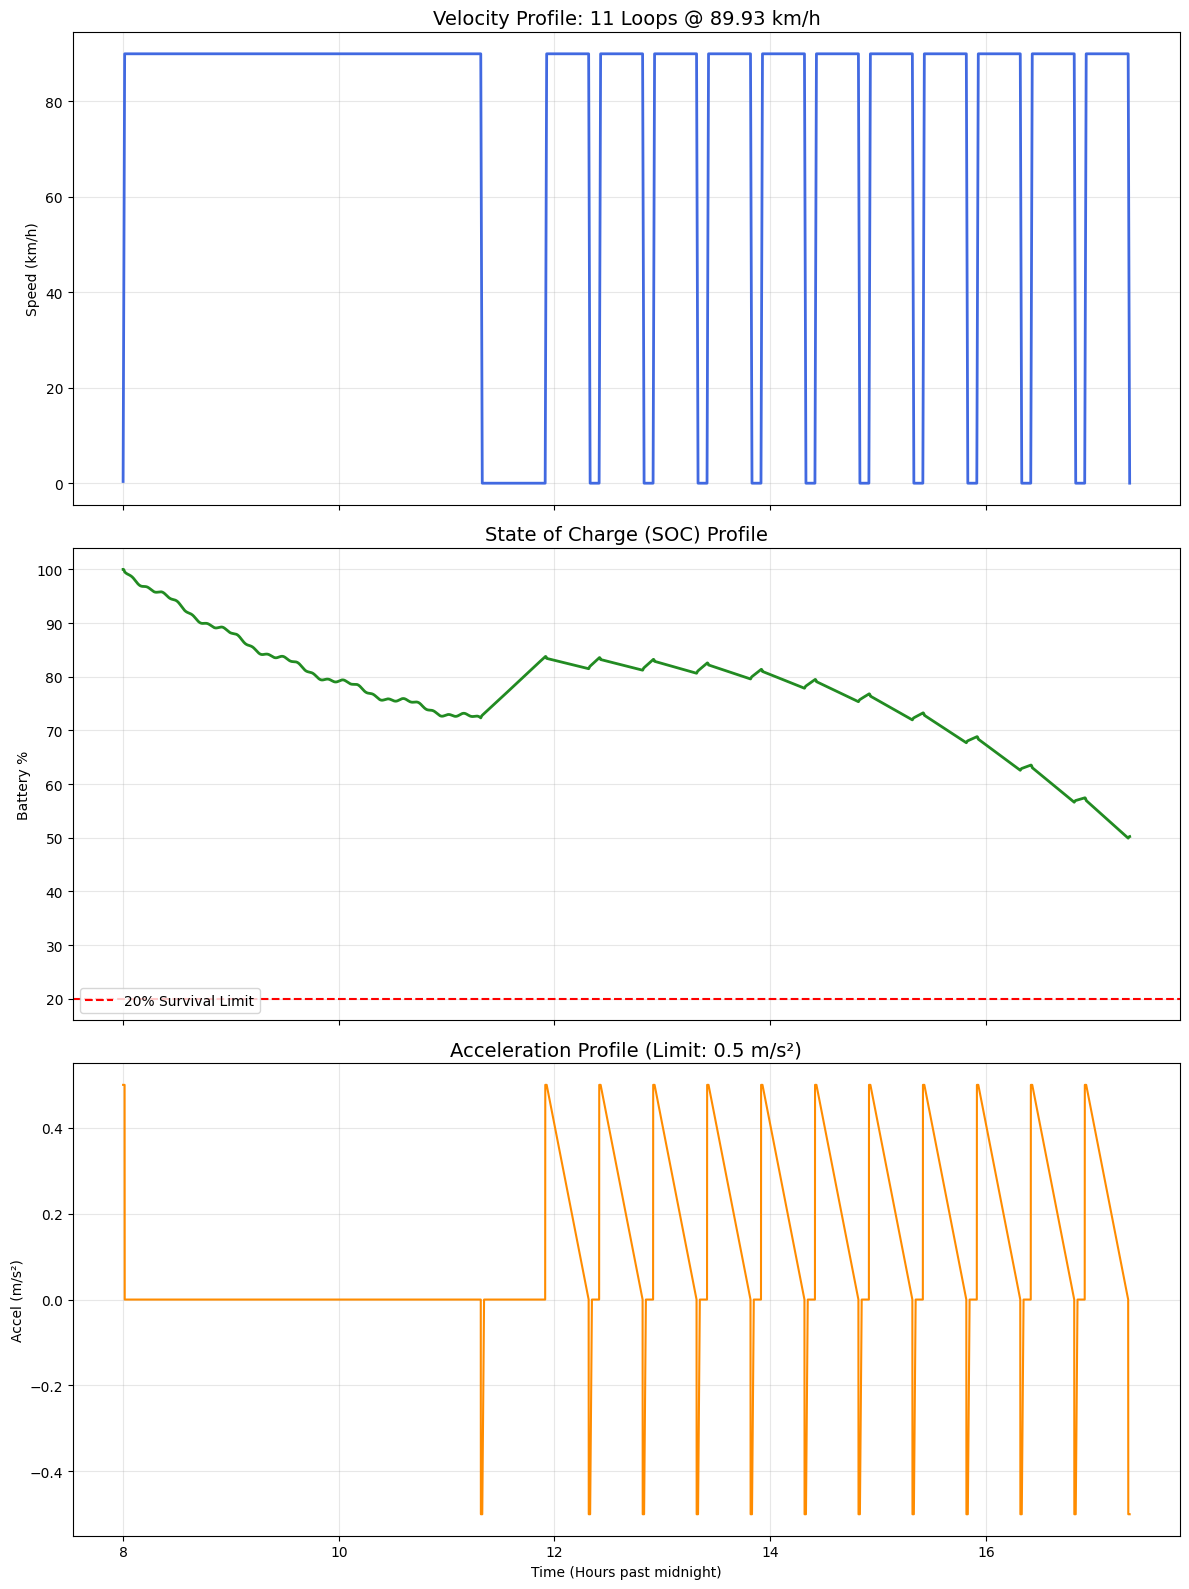

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. FINALIZED STRATEGY PARAMETERS ---
WINNING_N = 11
WINNING_V_KMH = 89.93
BATT_CAP_WH = 5000
MAX_PHYSICAL_ACCEL = 0.5  # m/s^2
SOC_MIN_LIMIT = 0.20

# Constant Defs
RHO, MASS, CDA, CRR, G = 1.225, 250, 0.0795, 0.00514, 9.81
MOTOR_EFF, REGEN_EFF = 0.90, 0.70
SOLAR_PEAK, SIGMA, MU = 1073, 11600, 12 * 3600
PANEL_AREA, PANEL_EFF = 4.0, 0.22

# Load Route Data generated in Phase 1
df = pd.read_csv("route_data.csv")

def get_solar_power(t):
    """Gaussian solar model"""
    return SOLAR_PEAK * np.exp(-((t - MU)**2) / (2 * SIGMA**2)) * PANEL_AREA * PANEL_EFF

# --- 2. MASTER SIMULATOR (PHASE 3) ---
def run_final_analysis(target_v_kmh, n_loops):
    target_v = target_v_kmh / 3.6
    curr_v, t, soc_wh = 0.0, 8 * 3600, BATT_CAP_WH
    history = {'t': [], 'v': [], 'soc': [], 'a': []}

    def log_step(v, a, dt, slope=0):
        nonlocal t, soc_wh, curr_v
        # Power = (Drag + Rolling + Gravity + Inertia) * Velocity
        p_mech = ((0.5*RHO*CDA*v**2) + (MASS*G*CRR*np.cos(slope)) +
                  (MASS*G*np.sin(slope)) + (MASS*a)) * v

        p_elec = p_mech / MOTOR_EFF if p_mech >= 0 else p_mech * REGEN_EFF
        soc_wh += (get_solar_power(t) - p_elec) * (dt / 3600)
        t += dt
        curr_v = v

        history['t'].append(t/3600)
        history['v'].append(v*3.6)
        history['soc'].append((soc_wh/BATT_CAP_WH)*100)
        history['a'].append(a)

    def drive_ramp(goal_v):
        """Smooth trapezoidal velocity ramping"""
        dt = 0.2
        while abs(curr_v - goal_v) > 0.01:
            accel = MAX_PHYSICAL_ACCEL if goal_v > curr_v else -MAX_PHYSICAL_ACCEL
            if abs(goal_v - curr_v) < abs(accel * dt):
                dt_final = abs(goal_v - curr_v) / MAX_PHYSICAL_ACCEL
                log_step(goal_v, accel, dt_final)
                break
            log_step(curr_v + accel * dt, accel, dt)

    # A. Base Route
    drive_ramp(target_v)
    for i in range(len(df)):
        dt = 50 / curr_v if curr_v > 0 else 1.0
        log_step(curr_v, 0, dt, df['slope_rad'].iloc[i])

    # B. 30-Min Stop (Zeerust)
    drive_ramp(0)
    for _ in range(30): log_step(0, 0, 60)

    # C. Optional Loops
    for _ in range(n_loops):
        # 5-min Mandatory Stop
        for _ in range(5): log_step(0, 0, 60)

        drive_ramp(target_v)
        loop_time = 35000 / target_v
        log_step(target_v, 0, loop_time)
        drive_ramp(0)

    return history

# --- 3. EXECUTION & PLOTTING ---
data = run_final_analysis(WINNING_V_KMH, WINNING_N)

fig, axs = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
plt.subplots_adjust(hspace=0.3)

# Velocity Profile
axs[0].plot(data['t'], data['v'], color='royalblue', lw=2)
axs[0].set_title(f"Velocity Profile: {WINNING_N} Loops @ {WINNING_V_KMH} km/h", fontsize=14)
axs[0].set_ylabel("Speed (km/h)")
axs[0].grid(True, alpha=0.3)

# SOC Profile
axs[1].plot(data['t'], data['soc'], color='forestgreen', lw=2)
axs[1].axhline(y=20, color='red', linestyle='--', label='20% Survival Limit')
axs[1].set_title("State of Charge (SOC) Profile", fontsize=14)
axs[1].set_ylabel("Battery %")
axs[1].legend(loc='lower left')
axs[1].grid(True, alpha=0.3)

# Acceleration Profile
axs[2].plot(data['t'], data['a'], color='darkorange', lw=1.5)
axs[2].set_title(f"Acceleration Profile (Limit: {MAX_PHYSICAL_ACCEL} m/s²)", fontsize=14)
axs[2].set_ylabel("Accel (m/s²)")
axs[2].set_xlabel("Time (Hours past midnight)")
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("phase3_final_analysis.png", dpi=300)
plt.show()